# [SK 05 - AssistantAPI AGENT with AzureAssistantAgent (kernel AND plugin)](https://learn.microsoft.com/en-us/semantic-kernel/frameworks/agent/assistant-agent?pivots=programming-language-python)
## e.g. from `ChatCompletionAgent` to `AzureAssistantAgent` (or `OpenAIAssistantAgent`)
- Chat Completion API focuses on simple conversational exchanges
- Assistant API allows for dynamic, goal-driven interactions with additional features like code-interpreter and file-search

[Sample](https://github.com/microsoft/semantic-kernel/blob/main/python/samples/getting_started_with_agents/step7_assistant.py)

## **Semantic Kernel** `Chat Completion Agent` vs **(Azure) OpenAI** `Assistant Agent`
## ...which means `ChatCompletionAgent` vs `AzureAssistantAgent` / `OpenAIAssistantAgent`
Here we show how to create an **OpenAI Assistant** using Azure OpenAI, but may do the same thing with the "pure" OpenAI service.<br/>
Regardless of the framework used (Semantic Kernel in this case), the `AzureAssistantAgent` as well as `OpenAIAssistantAgent` are **OpenAI Assistants**, which allow for **function calling**, the use of **file search** and a **code interpreter**.<br/>
Assistant **Threads** are used to manage the **conversation state**, similar to a Semantic Kernel Chat History but hosted on the service side, and automatically managed by the OpenAI service.
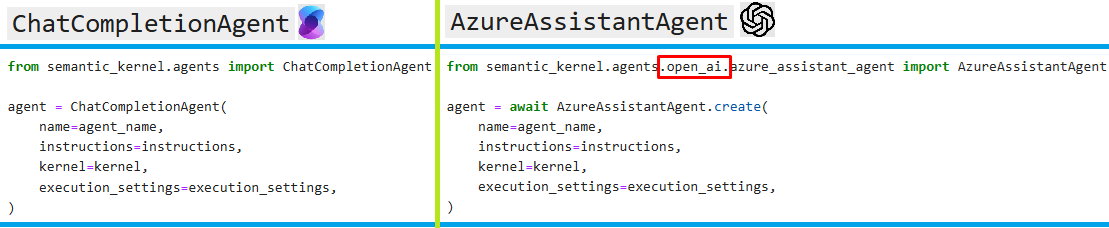

# Constants and Libraries

In [1]:
import os
from dotenv import load_dotenv # requires python-dotenv

load_dotenv("./../config/credentials_my.env")

agent_name                  = "mauromi_assistant_agent_python"
chatcompletion_service_id   = "chatcompletion_service_id"
instructions                = "you are a clever agent"
content                     = "Toggle the status of my second light."
plugin_name                 = "Lights"

print(f"os.environ['AZURE_OPENAI_ENDPOINT']: {os.environ['AZURE_OPENAI_ENDPOINT']}")

os.environ['AZURE_OPENAI_ENDPOINT']: https://mmoaiswc-01.openai.azure.com/


# Set the logging level for  semantic_kernel.kernel to DEBUG
One of the main benefits of using Semantic Kernel is that it supports enterprise-grade services.<br/>
In this sample, we add the logging service to the kernel to help debug the AI agent.

In [2]:
import logging

logging.basicConfig(
    format="[%(asctime)s - %(name)s:%(lineno)d - %(levelname)s] %(message)s",
    datefmt="%Y-%m-%d %H:%M:%S")
    
logging.getLogger("kernel").setLevel(logging.DEBUG)

# Create the Kernel, that does ***NOT*** contain any reference to the LLM

In [3]:
from semantic_kernel import Kernel

kernel = Kernel()

# Define a native plugin, then add it to the kernel

In [4]:
# First, we define the plugin through its class...

class LightsPlugin:
    from typing import Annotated
    from semantic_kernel.functions import kernel_function
    
    lights = [
        {"id": 0, "name": "Table Lamp", "is_on": False},
        {"id": 1, "name": "Porch light", "is_on": False},
        {"id": 2, "name": "Chandelier", "is_on": True},
    ]

    @kernel_function(
        name="get_lights", # <<<=== DIFFERENT FROM THE FUNCTION NAME <get_state>, which will be ignored
        description="Gets a list of lights and their current state",
    )
    def get_state(
        self,
    ) -> Annotated[str, "the output is a string"]:
        """Gets a list of lights and their current state."""
        return self.lights

    @kernel_function(
        name="change_state",
        description="Changes the state of the light",
    )
    def change_state(
        self,
        id: int,
        is_on: bool,
    ) -> Annotated[str, "the output is a string"]:
        """Changes the state of the light."""
        for light in self.lights:
            if light["id"] == id:
                light["is_on"] = is_on
                return light
        return None

In [5]:
# ...then, we add the plugin to the kernel, using a new plugin name

kernel.add_plugin(
    plugin      = LightsPlugin(),
    plugin_name = plugin_name,
)

KernelPlugin(name='Lights', description=None, functions={'change_state': KernelFunctionFromMethod(metadata=KernelFunctionMetadata(name='change_state', plugin_name='Lights', description='Changes the state of the light', parameters=[KernelParameterMetadata(name='id', description=None, default_value=None, type_='int', is_required=True, type_object=<class 'int'>, schema_data={'type': 'integer'}, include_in_function_choices=True), KernelParameterMetadata(name='is_on', description=None, default_value=None, type_='bool', is_required=True, type_object=<class 'bool'>, schema_data={'type': 'boolean'}, include_in_function_choices=True)], is_prompt=False, is_asynchronous=False, return_parameter=KernelParameterMetadata(name='return', description='the output is a string', default_value=None, type_='str', is_required=True, type_object=<class 'str'>, schema_data={'type': 'string', 'description': 'the output is a string'}, include_in_function_choices=True), additional_properties={}), invocation_duratio

# Enable planning with Function Calling set as Auto()

In [6]:
from semantic_kernel.connectors.ai.open_ai.prompt_execution_settings.azure_chat_prompt_execution_settings import AzureChatPromptExecutionSettings
from semantic_kernel.connectors.ai.function_choice_behavior import FunctionChoiceBehavior # Auto(), Required() or NoneInvoke()

execution_settings = AzureChatPromptExecutionSettings()
execution_settings.function_choice_behavior= FunctionChoiceBehavior.Auto() # Auto(), Required() or NoneInvoke()
execution_settings

AzureChatPromptExecutionSettings(service_id=None, extension_data={}, function_choice_behavior=FunctionChoiceBehavior(enable_kernel_functions=True, maximum_auto_invoke_attempts=5, filters=None, type_=<FunctionChoiceType.AUTO: 'auto'>), ai_model_id=None, frequency_penalty=None, logit_bias=None, max_tokens=None, number_of_responses=None, presence_penalty=None, seed=None, stop=None, stream=False, temperature=None, top_p=None, user=None, store=None, metadata=None, response_format=None, function_call=None, functions=None, messages=None, parallel_tool_calls=None, tools=None, tool_choice=None, structured_json_response=False, stream_options=None, max_completion_tokens=None, reasoning_effort=None, extra_body=None)

# Create the Assistant API Agent on Azure (AzureAssistantAgent)
# VERY IMPORTANT, POSSIBLE BUG
Make sure that the constant value for DEFAULT_AZURE_API_VERSION in `envs\<semantic_kernel_env_name>\Lib\site-packages\semantic_kernel\connectors\ai\open_ai\const.py` matches your `OPENAI_API_VERSION` environment value (listed for example in credentials_my.env).<br/>

For example, a good value is `2024-10-01-preview`:
- `DEFAULT_AZURE_API_VERSION: Final[str] = "2024-10-01-preview"` in **const.py**
- `OPENAI_API_VERSION = "2024-10-01-preview"` in **credentials_my.env**

Instead, by default in `semantic-kernel==1.21.1` installed on 17/02/2025, the **WRONG VALUE** is `DEFAULT_AZURE_API_VERSION: Final[str] = "2024-10-21"`

In [7]:
from semantic_kernel.agents.open_ai.azure_assistant_agent import AzureAssistantAgent
from semantic_kernel.functions.kernel_arguments import KernelArguments

agent = await AzureAssistantAgent.create(
    name=agent_name,
    instructions=instructions,
    kernel=kernel,
    # previously, we used: execution_settings=execution_settings. Now (like in .NET):
    arguments=KernelArguments(settings=execution_settings)
)

agent

AzureAssistantAgent(id='159ad613-1415-4acc-adb7-0de41b603e28', description=None, name='mauromi_assistant_agent_python', instructions='you are a clever agent', kernel=Kernel(retry_mechanism=PassThroughWithoutRetry(), services={}, ai_service_selector=<semantic_kernel.services.ai_service_selector.AIServiceSelector object at 0x0000029606468D40>, plugins={'Lights': KernelPlugin(name='Lights', description=None, functions={'change_state': KernelFunctionFromMethod(metadata=KernelFunctionMetadata(name='change_state', plugin_name='Lights', description='Changes the state of the light', parameters=[KernelParameterMetadata(name='id', description=None, default_value=None, type_='int', is_required=True, type_object=<class 'int'>, schema_data={'type': 'integer'}, include_in_function_choices=True), KernelParameterMetadata(name='is_on', description=None, default_value=None, type_='bool', is_required=True, type_object=<class 'bool'>, schema_data={'type': 'boolean'}, include_in_function_choices=True)], is

# Create Thread and add a message to it

In [8]:
thread_id = await agent.create_thread()
print(f"type(thread_id): {type(thread_id)}, thread_id: {thread_id}")

type(thread_id): <class 'str'>, thread_id: thread_49wsHRx4uOERpwyj8I7z38bI


In [9]:
from semantic_kernel.contents.chat_message_content import ChatMessageContent
from semantic_kernel.contents.utils.author_role import AuthorRole

message = ChatMessageContent(role=AuthorRole.USER, content=content)

await agent.add_chat_message(thread_id=thread_id, message=message)

i =0
async for message in agent.get_thread_messages(thread_id):
    i += 1
    print(f">>> Message {i} - {message}\n")

>>> Message 1 - Toggle the status of my second light.



# Run the agent

In [10]:
async for message in agent.invoke(thread_id=thread_id):
    print(message)

The status of your second light, the "Porch light," has been toggled on.


# Check the message history through the thread id
**IMPORTANT**
- The Assistant Agent automatically manages the history through the thread.
- The list of message history in the thread starts with the most recent one to the oldest one.

In [11]:
i =0
async for message in agent.get_thread_messages(thread_id):
    i += 1
    print(f">>> Message {i} - {message}\n")

>>> Message 1 - The status of your second light, the "Porch light," has been toggled on.

>>> Message 2 - Toggle the status of my second light.



# Additional tests. Run multiple times to toggle the first light.

In [12]:
message = ChatMessageContent(role=AuthorRole.USER, content="Toggle the first light and give me the status of all my lights.")

await agent.add_chat_message(thread_id=thread_id, message=message)

async for message in agent.invoke(thread_id=thread_id):
    print(message)

messages = [message async for message in agent.get_thread_messages(thread_id)]
print(f"\n\nHere are all the {len(messages)} messages:\n")
for i, message in enumerate(reversed(messages), 1):
    print(f">>> Message {i} - {message}\n")

The status of your first light, the "Table Lamp," has been toggled on. Here is the current status of all your lights:

1. **Table Lamp**: On
2. **Porch light**: On
3. **Chandelier**: On


Here are all the 4 messages:

>>> Message 1 - Toggle the status of my second light.

>>> Message 2 - The status of your second light, the "Porch light," has been toggled on.

>>> Message 3 - Toggle the first light and give me the status of all my lights.

>>> Message 4 - The status of your first light, the "Table Lamp," has been toggled on. Here is the current status of all your lights:

1. **Table Lamp**: On
2. **Porch light**: On
3. **Chandelier**: On



# TEARDOWN

In [13]:
from openai import AzureOpenAI

# Create the client
client = AzureOpenAI(
    # api_key        = os.getenv("AZURE_OPENAI_API_KEY"),  
    # api_version    = os.getenv("AZURE_OPENAI_API_VERSION"), # at least 2024-02-15-preview
    # azure_endpoint = os.getenv("AZURE_OPENAI_ENDPOINT")
)
print(f"client.base_url: {client.base_url}")

client.base_url: https://mmoaiswc-01.openai.azure.com/openai/


In [14]:
# delete files

files_list = client.files.list().data
print(f"There are {len(files_list)} files to delete")

i = 0
for file in files_list:
    i += 1
    print(f"File {i}/{len(files_list)}: {file.filename} (id={file.id}) is being deleted...")
    client.files.delete(file.id) # un-comment this line if you want to delete it

There are 0 files to delete


In [15]:
print(f"Deleting thread {thread_id}...")
client.beta.threads.delete(thread_id)

Deleting thread thread_49wsHRx4uOERpwyj8I7z38bI...


ThreadDeleted(id='thread_49wsHRx4uOERpwyj8I7z38bI', deleted=True, object='thread.deleted')

In [16]:
# delete all assistant agents

assistants_list = client.beta.assistants.list().data
print(f"There are {len(assistants_list)} assistants to delete")

i = 0
for assistant in assistants_list:
    i += 1
    print(f"Assistant {i}/{len(assistants_list)}: Assistant {assistant.name} ({assistant.id})) is being deleted...")
    client.beta.assistants.delete(assistant_id=assistant.id) # un-comment this line if you want to delete it

There are 1 assistants to delete
Assistant 1/1: Assistant mauromi_assistant_agent_python (asst_sZO1CTaKXhvheO2mHyr3Hv6E)) is being deleted...
